# CarbonPulse Finland — Hourly Clean-First Pipeline
## Individual Source Cleaning → Hourly Aggregation → GRU,RNN & LSTM Training

**Project:** CarbonPulse Finland — Multi-Scale CO₂ Emission Forecasting & Analytics Driven Digital Twin
**Resolution:** 15-minute (aggregated from 3-minute, cleaned FIRST per source)
**Targets:** `co2_intensity_simple_avg` and `consumption_co2_intens_simple_avg` (gCO₂/kWh)
**Key improvement over 3-min pipeline:** Outliers removed at 3-min level before averaging — prevents a single sensor spike from corrupting a hourly bucket mean.

---
### Why Clean Before Aggregating?
If you aggregate first then clean, a single extreme spike (e.g. wind = 9,999 MW from a sensor glitch) gets averaged into the hourly mean. The outlier becomes invisible — it raises the bucket mean by ~500 MW without being detectable. Cleaning first at 3-min resolution removes the spike before the mean is computed.

---
### Pipeline Overview
| Stage | Description |
|-------|-------------|
| **0. Setup** | Imports, constants, helper functions |
| **1. Load & Raw Inspect** | Load each source, show shape/stats/gaps |
| **2. Clean Per Source** | Physical bounds → rolling z-score → forward-fill |
| **3. Visualise Cleaning** | Before/after outlier plots per source |
| **4. Aggregate to 15-min** | Mean per bucket (averages only, no sums) |
| **5. Merge** | inner-join all hourly frames on timestamp_utc |
| **6. EDA on Merged Data** | Distributions, correlations, seasonal patterns, ACF |
| **7. Feature Engineering** | Cyclical time, lags, rolling stats, physics features |
| **8. Split & Scale** | Time-based split, MinMaxScaler fit on train only |
| **9. Sequence Dataset** | On-demand windowed Dataset (avoids MemoryError) |
| **10. Train GRU** | Train and record loss per epoch |
| **11. Train LSTM** | Same architecture for fair comparison |
| **12. Evaluate & Compare** | MAE, RMSE, MAPE vs baselines |
| **13. Results Summary** | Full findings table and key observations |


---
## Stage 0 — Setup
**Purpose:** Centralise all imports, constants, and helper functions. Change a parameter once here — it applies everywhere.

In [207]:
import gc
import json
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
import joblib
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────
DB_PATH    = "data/project_data.db"


# ── Cleaning constants ──────────────────────────────────────
ZSCORE_WINDOW  = 480    # 24h at 3-min resolution (480 × 3min)
ZSCORE_THRESH  = 4.0    # flag if > 4σ from local rolling mean
FILL_LIMIT     = 5      # forward-fill ≤ 5 slots = 15 minutes max

# ── Physical bounds (Finland-specific) ─────────────────────
PHYSICAL_BOUNDS = {
    "co2_intensity":              (0,   500),
    "consumption_co2_intensity":  (0,   600),
    "wind":                       (0,  8000),
    "nuclear":                    (0,  5000),
    "hydro":                      (0,  3500),
    "chp_district":               (0,  5000),
    "chp_industrial":             (0,  3000),
    "total_production":           (0, 20000),
    "consumption_electricity":    (0, 20000),
}

# ── Source definitions ──────────────────────────────────────
# (db_table_name, output_column_label, type)
# type "mean"      = MW source  → compute mean + count
# type "intensity" = gCO2/kWh  → compute simple_avg + weighted_avg + count
SOURCES = [
    ("co2_intensity",              "co2_intensity",         "intensity"),
    ("consumption_co2_intensity",  "consumption_co2_intens","intensity"),
    ("chp_district",               "chp_district_mw",       "mean"),
    ("chp_industrial",             "chp_industrial_mw",     "mean"),
    ("hydro",                      "hydro_mw",              "mean"),
    ("nuclear",                    "nuclear_mw",            "mean"),
    ("wind",                       "wind_mw",               "mean"),
    ("total_production",           "total_production_mw",   "mean"),
    ("consumption_electricity",    "consumption_elec_mw",   "mean"),
]

INTENSITY_WEIGHTS = {
    "co2_intensity":             "total_production",
    "consumption_co2_intensity": "consumption_electricity",
}

TARGET_COLS          = ["co2_intensity_simple_avg",
                        "consumption_co2_intens_simple_avg"]
TARGET_COLS_WEIGHTED = ["co2_intensity_weighted_avg",
                        "consumption_co2_intens_weighted_avg"]

# ── Model constants ─────────────────────────────────────────
HORIZON    = 1       # predict 1 step ahead (next 15 minutes)
BATCH_SIZE = 64
EPOCHS     = 20
LR         = 1e-4
HIDDEN     = 64
LAYERS     = 2
DROPOUT    = 0.2


# ── Plot style ──────────────────────────────────────────────
BLUE   = "#264653"
TEAL   = "#2a9d8f"
AMBER  = "#e9c46a"
ORANGE = "#f4a261"
RED    = "#e76f51"
PURPLE = "#6d6875"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {device}")
print(f"PyTorch : {torch.__version__}")
print(f"Pandas  : {pd.__version__}")



Device  : cpu
PyTorch : 2.12.1+cpu
Pandas  : 3.0.3


In [ ]:
# --- Dynamic Sequence Length Selection ---
def get_sequence_length(freq_str: str) -> int | None:
    freq = freq_str.lower().strip()
    if freq in ["15min", "15-min", "15_min"]:
        return 80
    elif freq == "hourly":
        return 168
    elif freq == "daily":
        return 90
    elif freq == "weekly":
        return 52
    elif freq == "monthly":
        return 24
    elif freq == "yearly":
        return None  # Empty
    else:
        return 24  # Fallback default to your original value

# Set dynamically based on your target project grain selection
# Select target window: "15min", "hourly", "daily", "weekly", "monthly", "yearly"
TARGET_FREQUENCY = "15min" 
NO_LAG_ROLLING = True
SEQ_LEN = get_sequence_length(TARGET_FREQUENCY)
print(f"Configuration profile active: SEQ_LEN = {SEQ_LEN}")

# Used by the save cells below to route each experiment/frequency into its
# own folder: test/<frequency>/<all_features|no_lag_rolling>/
EXPERIMENT_NAME = "no_lag_rolling" if NO_LAG_ROLLING else "all_features"


Configuration profile active: SEQ_LEN = 80


In [209]:
# Match the exact same directory routing strategy for your images
OUTPUT_DIR = Path("outputs") / TARGET_FREQUENCY / EXPERIMENT_NAME

# This line ensures all parent and child folders are generated seamlessly
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

---
## Stage 1 — Load Each Source and Raw Inspection
**Purpose:** Load all 9 raw 3-minute source tables from SQLite and inspect them BEFORE any cleaning.
Observation only — no changes made here.

**Why inspect raw data first?**
- Reveals the scale and type of data quality issues
- Sets the baseline for measuring how much cleaning removes
- Documents the original state for the data quality report


In [210]:
def load_raw(table_name: str) -> pd.DataFrame:
    conn = sqlite3.connect(DB_PATH)
    try:
        df = pd.read_sql(
            f'SELECT start_time, value FROM "{table_name}" ORDER BY start_time',
            conn
        )
    finally:
        conn.close()
    df["start_time"] = pd.to_datetime(df["start_time"], utc=True)
    df = (df.drop_duplicates(subset=["start_time"])
            .sort_values("start_time")
            .reset_index(drop=True))
    return df

# Load all sources into memory
print("Loading all raw source tables...")
raw_data = {}
for table_name, label, agg_type in SOURCES:
    df = load_raw(table_name)
    raw_data[table_name] = df
    print(f"  {table_name:30s}: {len(df):>10,} rows  "
          f"[{df['start_time'].iloc[0].strftime('%Y-%m-%d')} -> "
          f"{df['start_time'].iloc[-1].strftime('%Y-%m-%d')}]")


Loading all raw source tables...
  co2_intensity                 :  1,544,078 rows  [2018-01-01 -> 2026-08-16]
  consumption_co2_intensity     :  1,543,768 rows  [2018-01-01 -> 2026-08-16]
  chp_district                  :  1,546,910 rows  [2018-01-01 -> 2026-08-16]
  chp_industrial                :  1,546,532 rows  [2018-01-01 -> 2026-08-16]
  hydro                         :  1,546,629 rows  [2018-01-01 -> 2026-08-16]
  nuclear                       :  1,546,523 rows  [2018-01-01 -> 2026-08-16]
  wind                          :  1,538,265 rows  [2018-01-01 -> 2026-08-16]
  total_production              :  1,545,170 rows  [2018-01-01 -> 2026-08-16]
  consumption_electricity       :  1,545,181 rows  [2018-01-01 -> 2026-08-16]


In [211]:
# ── Raw descriptive statistics for all sources ──────────────
print("=== RAW DESCRIPTIVE STATISTICS ===\n")
for table_name, label, _ in SOURCES:
    df = raw_data[table_name]
    v  = df["value"]
    print(f"{table_name}:")
    print(f"  count={len(v):,}  NaN={v.isna().sum():,}  "
          f"min={v.min():.1f}  max={v.max():.1f}  "
          f"mean={v.mean():.1f}  std={v.std():.1f}")
    # Gap analysis
    diffs    = df["start_time"].diff().dt.total_seconds()
    n_gaps   = (diffs > 180).sum()
    max_gap  = diffs.max()
    print(f"  gaps>3min={n_gaps:,}  max_gap={max_gap/3600:.1f}h")
    print()


=== RAW DESCRIPTIVE STATISTICS ===

co2_intensity:
  count=1,544,078  NaN=0  min=7.9  max=183.2  mean=57.9  std=33.4
  gaps>3min=7,805  max_gap=19.1h

consumption_co2_intensity:
  count=1,543,768  NaN=0  min=7.9  max=245.8  mean=63.2  std=40.7
  gaps>3min=8,131  max_gap=19.1h

chp_district:
  count=1,546,910  NaN=0  min=0.0  max=3569.1  mean=893.2  std=739.8
  gaps>3min=13,759  max_gap=19.1h

chp_industrial:
  count=1,546,532  NaN=0  min=328.1  max=2739.7  mean=1156.8  std=265.5
  gaps>3min=13,742  max_gap=19.1h

hydro:
  count=1,546,629  NaN=0  min=168.3  max=2675.5  mean=1490.9  std=506.1
  gaps>3min=13,702  max_gap=19.1h

nuclear:
  count=1,546,523  NaN=0  min=823.0  max=4414.8  mean=3057.1  std=737.2
  gaps>3min=13,740  max_gap=19.1h

wind:
  count=1,538,265  NaN=0  min=-25.0  max=7655.9  mean=1406.9  std=1348.3
  gaps>3min=17,678  max_gap=17.9h

total_production:
  count=1,545,170  NaN=0  min=3932.1  max=15489.0  mean=8185.2  std=1769.4
  gaps>3min=13,726  max_gap=19.1h

consumpti

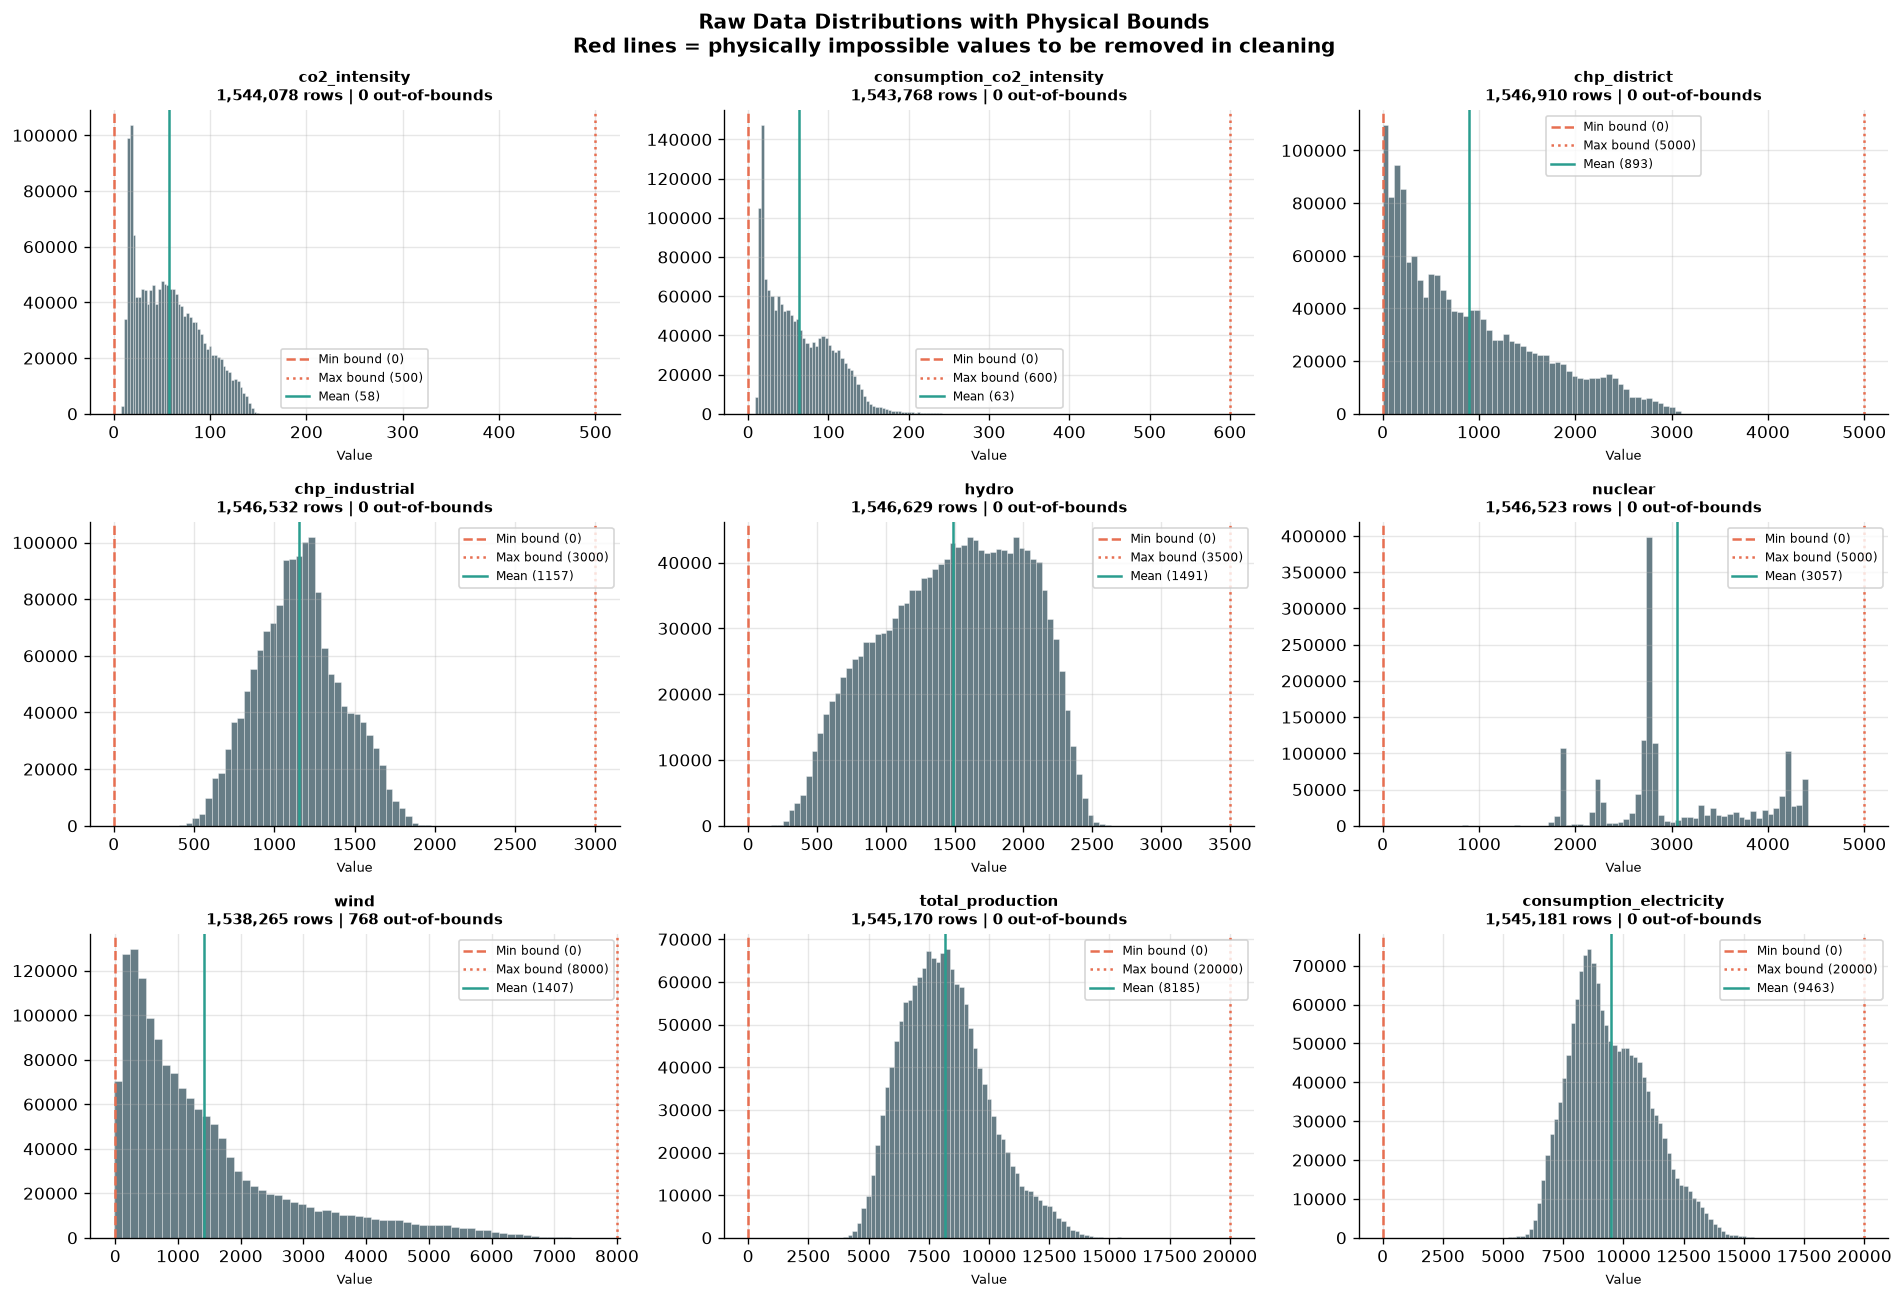

KEY FINDING: Any bars outside the red lines = impossible values = sensor errors.


In [212]:
# ── Raw distribution overview ───────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for i, (table_name, label, _) in enumerate(SOURCES):
    ax  = axes[i]
    v   = raw_data[table_name]["value"].dropna()
    lo, hi = PHYSICAL_BOUNDS[table_name]

    ax.hist(v, bins=60, color=BLUE, edgecolor="white", linewidth=0.3, alpha=0.7)
    ax.axvline(lo, color=RED,   lw=1.5, linestyle="--", label=f"Min bound ({lo})")
    ax.axvline(hi, color=RED,   lw=1.5, linestyle=":",  label=f"Max bound ({hi})")
    ax.axvline(v.mean(), color=TEAL, lw=1.5, label=f"Mean ({v.mean():.0f})")

    n_out = ((v < lo) | (v > hi)).sum()
    ax.set_title(f"{table_name}\n{len(v):,} rows | {n_out} out-of-bounds",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("Value", fontsize=8)
    ax.legend(fontsize=7)

for j in range(len(SOURCES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Raw Data Distributions with Physical Bounds\n"
             "Red lines = physically impossible values to be removed in cleaning",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/stage1_raw_distributions.png",
            dpi=130, bbox_inches="tight")
plt.show()
print("KEY FINDING: Any bars outside the red lines = impossible values = sensor errors.")


---
## Stage 2 — Clean Each Source at 3-Minute Resolution
**This is the core innovation of this pipeline.** Cleaning at 3-min resolution ensures that a sensor spike is removed BEFORE it can contaminate a 15-min average.

**Three cleaning steps per source:**
1. **Physical bounds** — set values outside Finland's physically possible range to NaN
2. **Rolling z-score** — flag values > 4σ from the 24-hour rolling mean. A static z-score would incorrectly flag real winter intensity peaks (150+ gCO₂/kWh); rolling keeps the reference local
3. **Forward-fill** — fill NaN from steps 1 and 2 for short gaps ≤ 15 minutes. Longer gaps remain NaN and contribute zero slots to the 15-min count column

**Why threshold = 4.0σ not 3.0σ?**
At 3σ we expect 0.3% of values flagged — including genuine winter intensity extremes. At 4σ only ~0.006% are expected under a normal distribution, meaning only genuine spikes are removed.


In [213]:
def clean_source_3min(table_name: str, df_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_raw.rename(columns={"value": table_name}).set_index("start_time").copy()
    lo, hi = PHYSICAL_BOUNDS[table_name]

    # Step 1: Physical bounds
    n_lo = (df[table_name] < lo).sum()
    n_hi = (df[table_name] > hi).sum()
    df.loc[df[table_name] < lo, table_name] = np.nan
    df.loc[df[table_name] > hi, table_name] = np.nan

    # Step 2: Rolling z-score
    roll_mean = (df[table_name]
                 .rolling(ZSCORE_WINDOW, center=True,
                          min_periods=int(ZSCORE_WINDOW*0.5)).mean())
    roll_std  = (df[table_name]
                 .rolling(ZSCORE_WINDOW, center=True,
                          min_periods=int(ZSCORE_WINDOW*0.5)).std()
                 .replace(0, np.nan))
    z = (df[table_name] - roll_mean).abs() / roll_std
    mask = z > ZSCORE_THRESH
    df[f"{table_name}_zscore_flag"] = mask.astype(np.int8)
    df.loc[mask, table_name] = np.nan
    n_z = mask.sum()

    # Step 3: Forward-fill short gaps (≤ FILL_LIMIT slots = 15 min)
    filled = df[table_name].ffill(limit=FILL_LIMIT)
    df[f"{table_name}_filled_flag"] = (df[table_name].isna() & filled.notna()).astype(np.int8)
    n_filled = df[f"{table_name}_filled_flag"].sum()
    df[table_name] = filled
    n_still_nan = df[table_name].isna().sum()

    coverage = df[table_name].notna().mean() * 100

    print(f"  {table_name:30s}: bounds={n_lo+n_hi:4d}  z-score={n_z:4,}  "
          f"filled={n_filled:4,}  remaining_nan={n_still_nan:4,}  "
          f"coverage={coverage:.2f}%")
    return df

print("Cleaning all sources at 3-minute resolution...")
print(f"{'Source':30s}  {'bounds':>7}  {'z-score':>8}  {'filled':>7}  "
      f"{'rem_nan':>9}  {'coverage':>9}")
print("-" * 75)

cleaned = {}
for table_name, label, _ in SOURCES:
    cleaned[table_name] = clean_source_3min(table_name, raw_data[table_name])
    gc.collect()

print("\nCleaning complete.")


Cleaning all sources at 3-minute resolution...
Source                           bounds   z-score   filled    rem_nan   coverage
---------------------------------------------------------------------------
  co2_intensity                 : bounds=   0  z-score= 867  filled= 533  remaining_nan= 334  coverage=99.98%
  consumption_co2_intensity     : bounds=   0  z-score= 917  filled= 569  remaining_nan= 348  coverage=99.98%
  chp_district                  : bounds=   0  z-score= 272  filled= 203  remaining_nan=  69  coverage=100.00%
  chp_industrial                : bounds=   0  z-score= 818  filled= 810  remaining_nan=   8  coverage=100.00%
  hydro                         : bounds=   0  z-score=   0  filled=   0  remaining_nan=   0  coverage=100.00%
  nuclear                       : bounds=   0  z-score=1,511  filled= 925  remaining_nan= 586  coverage=99.96%
  wind                          : bounds= 768  z-score=   3  filled= 111  remaining_nan= 660  coverage=99.96%
  total_production    

---
## Stage 3 — Visualise Cleaning Results
**Purpose:** Confirm that cleaning removed the right values (genuine errors) without removing real extremes (winter peaks, low-wind periods).

**Two plots per source:**
- Before/after time series overlay (sample period)
- Before/after distribution comparison


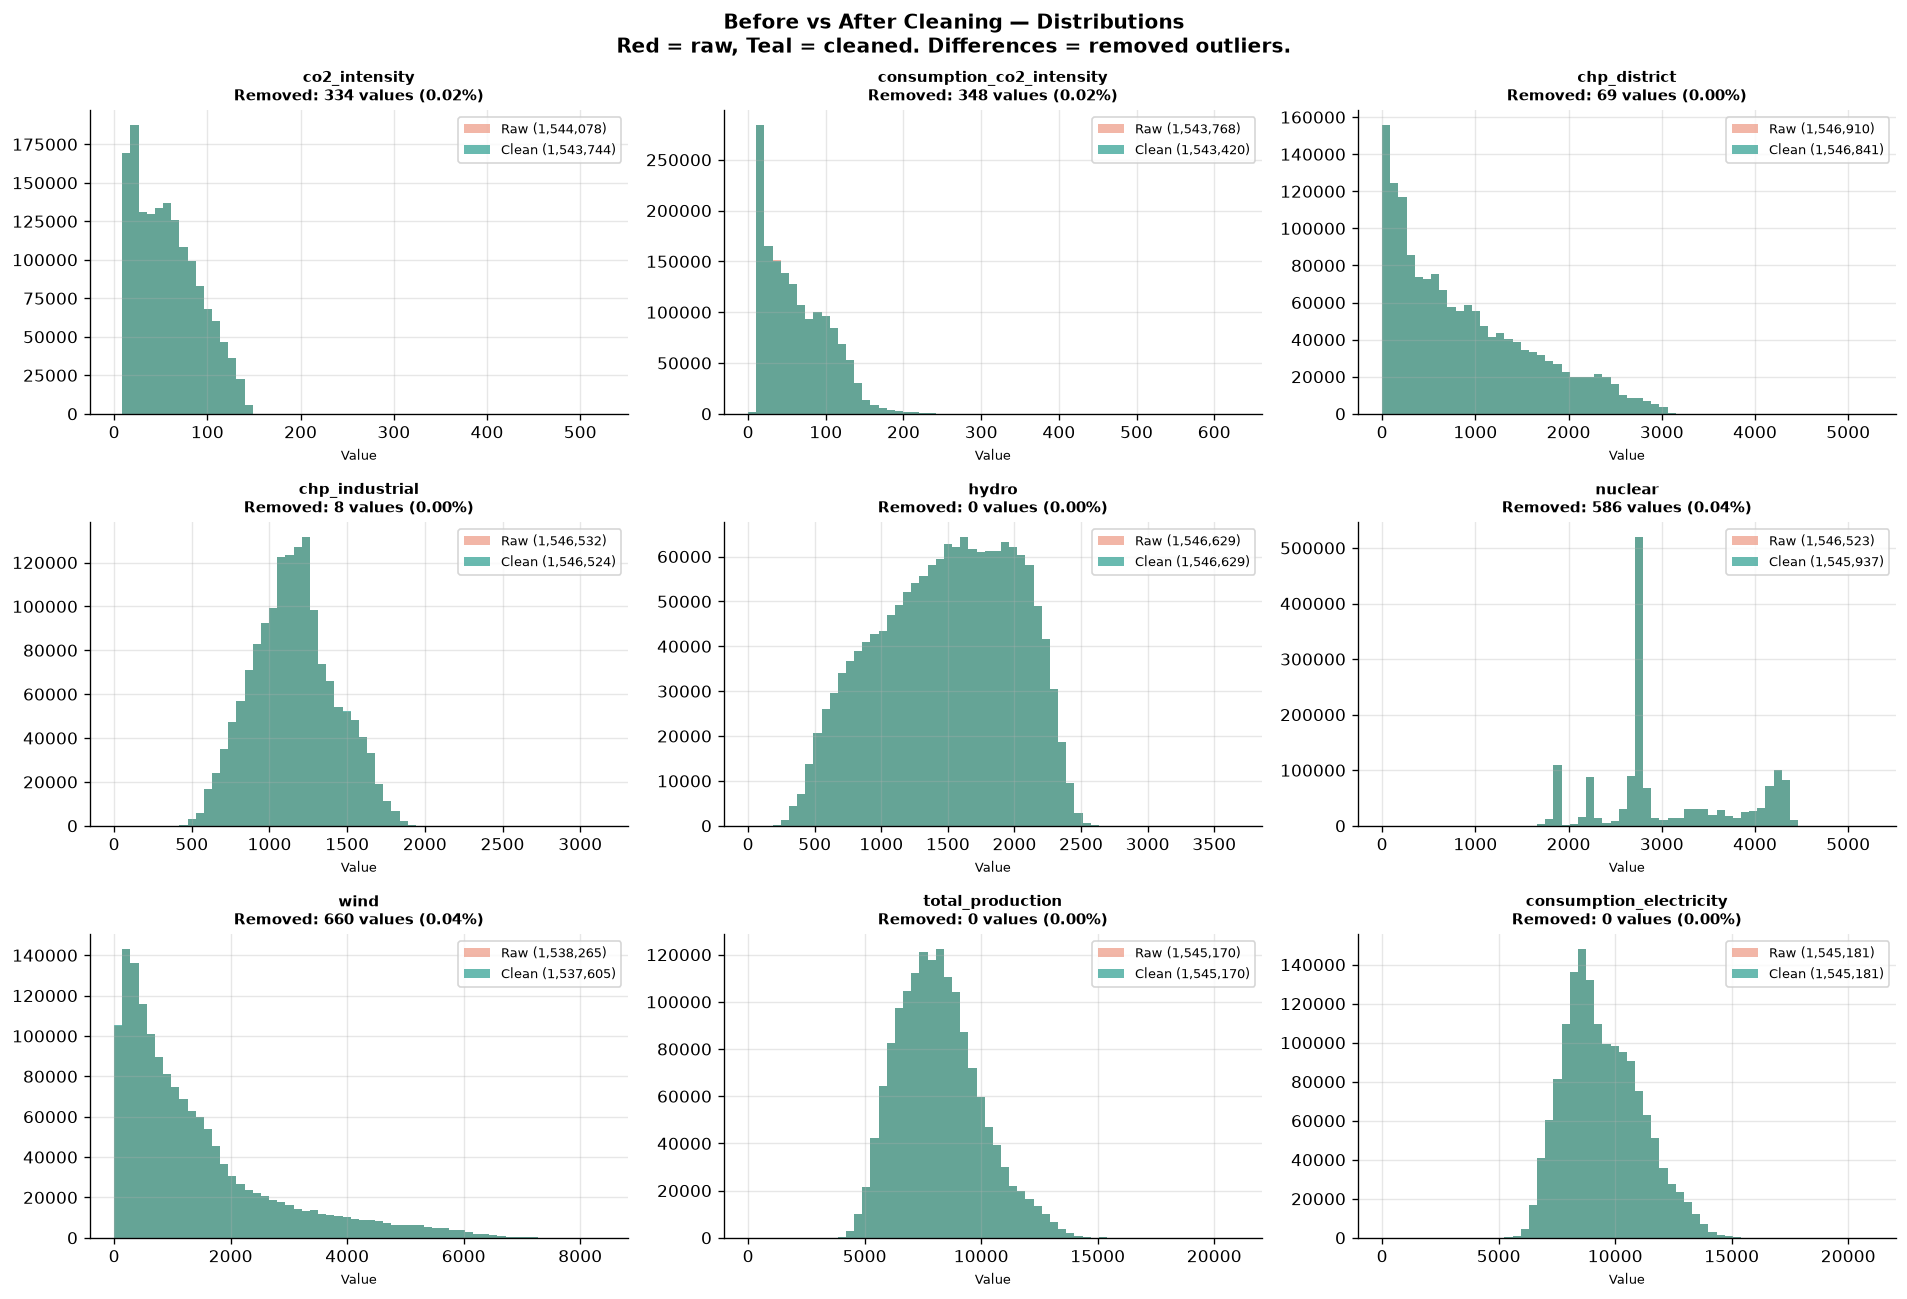

In [214]:
# ── Before/after distribution comparison for each source ────
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for i, (table_name, label, _) in enumerate(SOURCES):
    ax   = axes[i]
    raw  = raw_data[table_name]["value"].dropna()
    cln  = cleaned[table_name][table_name].dropna()

    lo, hi = PHYSICAL_BOUNDS[table_name]
    xlim   = (max(lo - hi*0.05, lo), hi * 1.05)

    ax.hist(raw, bins=60, color=RED,  alpha=0.5, label=f"Raw ({len(raw):,})",
            range=xlim)
    ax.hist(cln, bins=60, color=TEAL, alpha=0.7, label=f"Clean ({len(cln):,})",
            range=xlim)

    n_removed = len(raw) - len(cln)
    ax.set_title(f"{table_name}\nRemoved: {n_removed:,} values "
                 f"({n_removed/len(raw)*100:.2f}%)",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("Value", fontsize=8)
    ax.legend(fontsize=8)

for j in range(len(SOURCES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Before vs After Cleaning — Distributions\n"
             "Red = raw, Teal = cleaned. Differences = removed outliers.",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/stage3_cleaning_distributions.png",
            dpi=130, bbox_inches="tight")
plt.show()


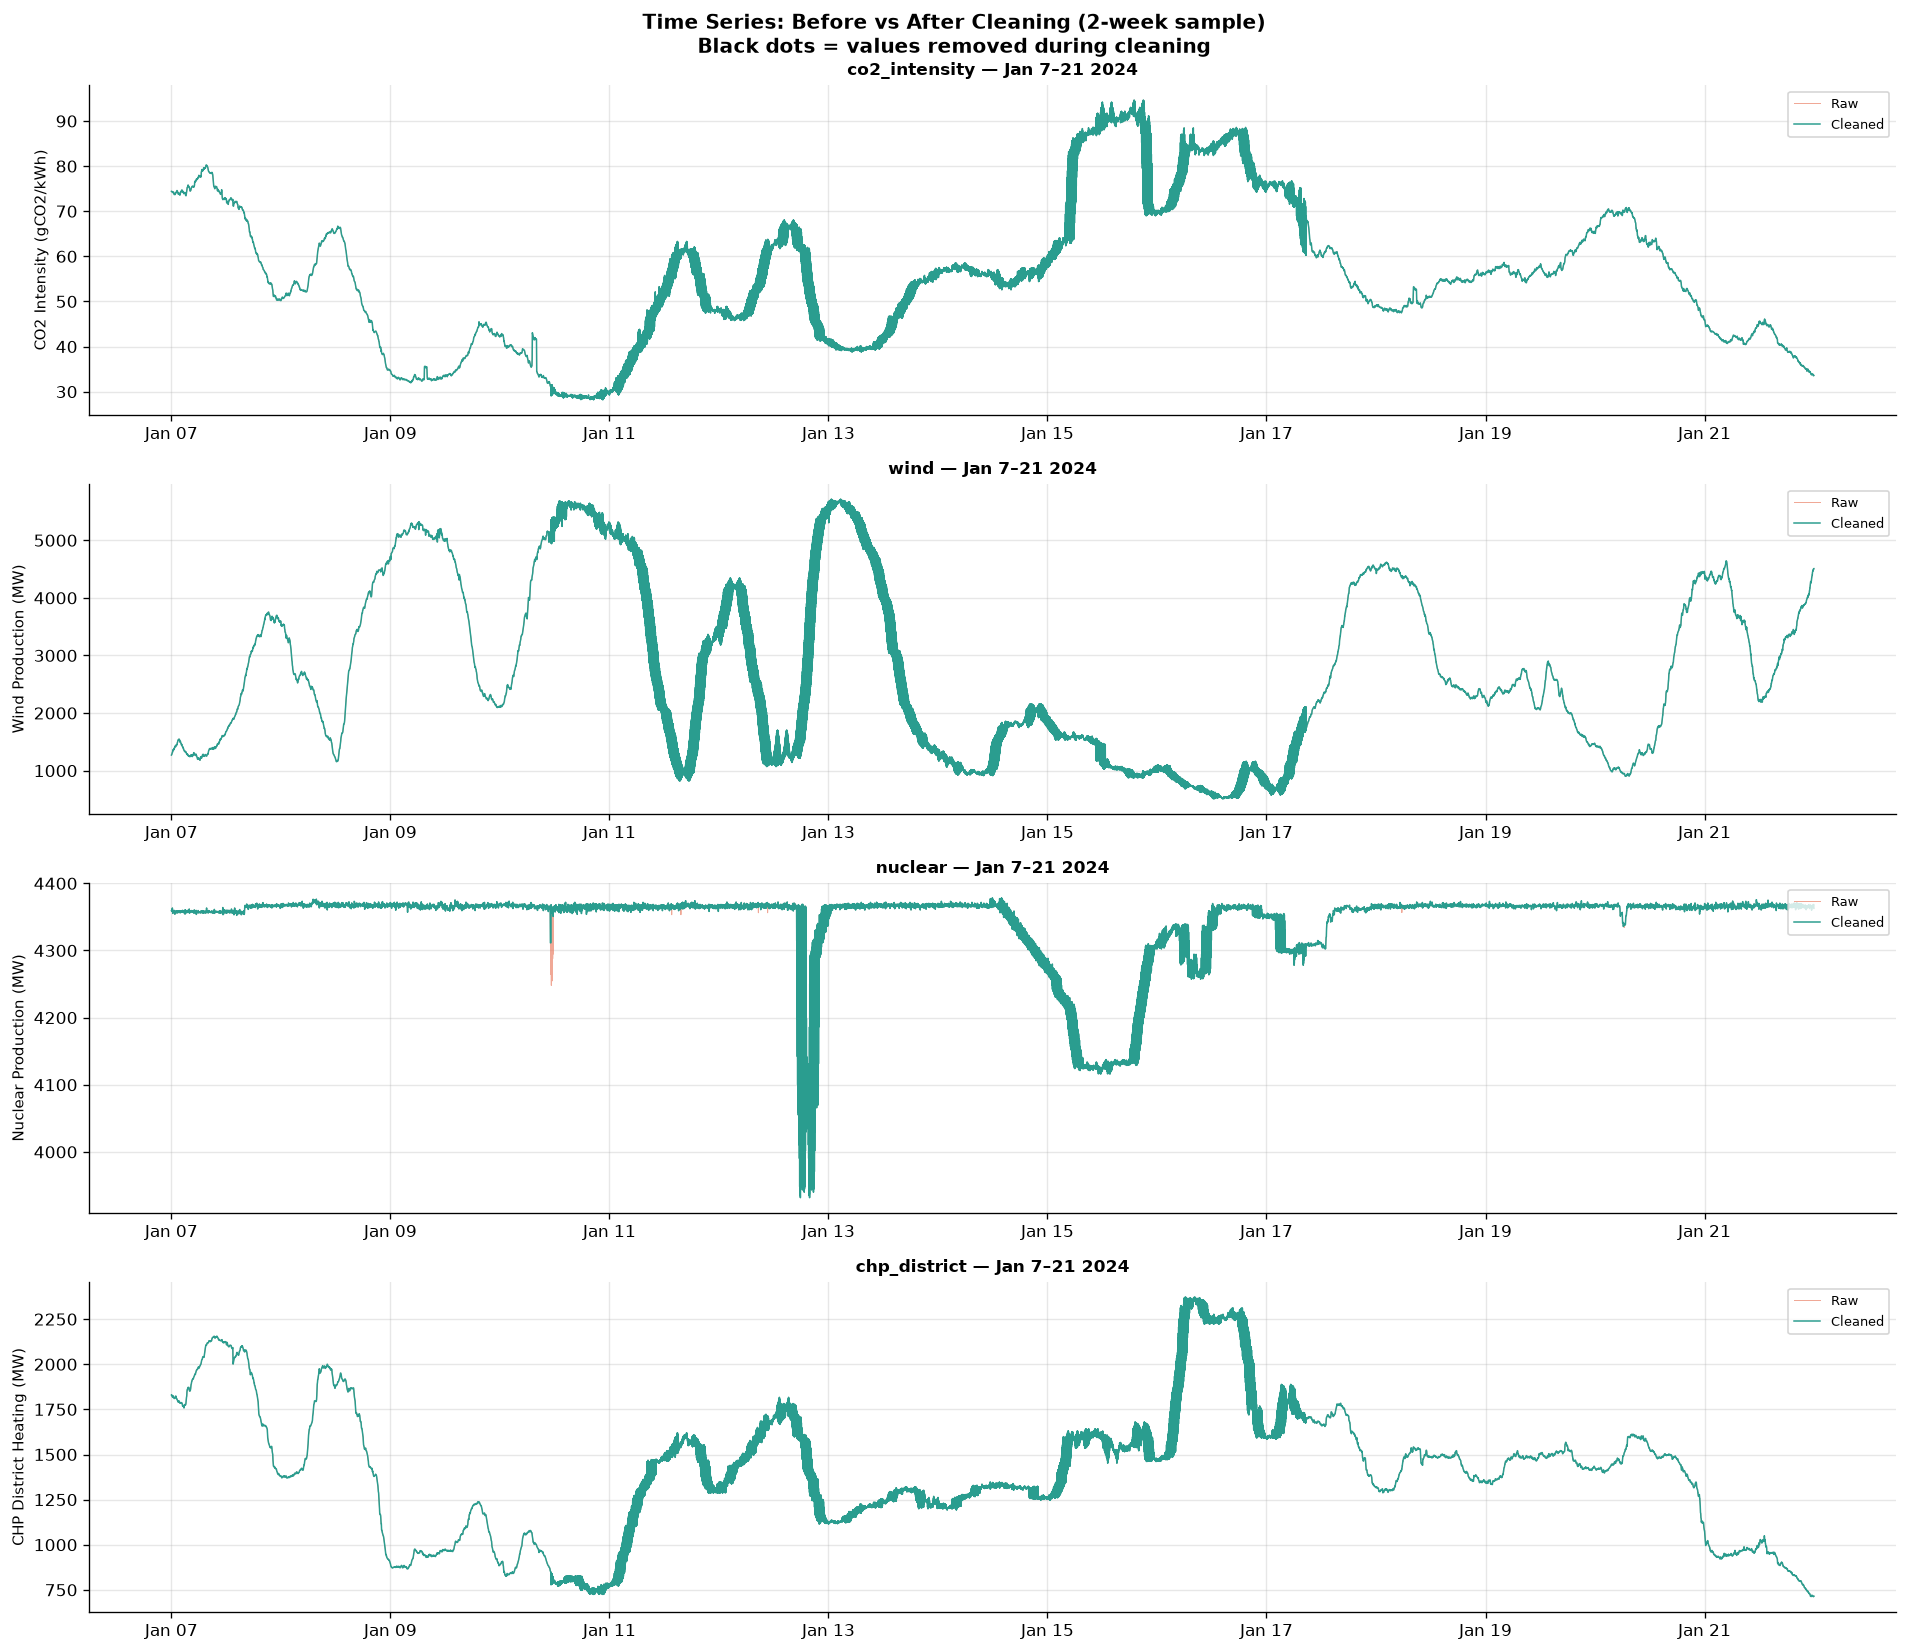

In [215]:
# ── Time series: before vs after for key sources ───────────
KEY_SOURCES = [
    ("co2_intensity",   "CO2 Intensity (gCO2/kWh)"),
    ("wind",            "Wind Production (MW)"),
    ("nuclear",         "Nuclear Production (MW)"),
    ("chp_district",    "CHP District Heating (MW)"),
]

fig, axes = plt.subplots(len(KEY_SOURCES), 1, figsize=(16, 14), sharex=False)

# Sample period: 2 weeks from Jan 2024
SAMPLE_START = "2024-01-07"
SAMPLE_END   = "2024-01-21"

for ax, (table_name, ylabel) in zip(axes, KEY_SOURCES):
    raw   = raw_data[table_name].set_index("start_time")["value"]
    cln   = cleaned[table_name][table_name]

    raw_s = raw[SAMPLE_START:SAMPLE_END]
    cln_s = cln[SAMPLE_START:SAMPLE_END]

    ax.plot(raw_s.index, raw_s.values,
            color=RED, lw=0.6, alpha=0.6, label="Raw")
    ax.plot(cln_s.index, cln_s.values,
            color=TEAL, lw=0.9, label="Cleaned")

    # Highlight removed points
    removed_mask = raw_s.notna() & cln_s.isna()
    if removed_mask.sum() > 0:
        ax.scatter(raw_s[removed_mask].index, raw_s[removed_mask].values,
                   color="black", s=25, zorder=5, label="Removed")

    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_title(f"{table_name} — Jan 7–21 2024", fontsize=10, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.suptitle("Time Series: Before vs After Cleaning (2-week sample)\n"
             "Black dots = values removed during cleaning",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/stage3_cleaning_timeseries.png",
            dpi=130, bbox_inches="tight")
plt.show()


Total z-score outliers in co2_intensity: 867

Outlier timestamps (first 10):
[Timestamp('2018-01-02 08:30:00+0000', tz='UTC'), Timestamp('2018-01-02 08:33:00+0000', tz='UTC'), Timestamp('2018-01-02 08:36:00+0000', tz='UTC'), Timestamp('2018-01-02 08:39:00+0000', tz='UTC'), Timestamp('2018-02-13 07:18:00+0000', tz='UTC'), Timestamp('2018-02-13 07:21:00+0000', tz='UTC'), Timestamp('2018-02-13 07:24:00+0000', tz='UTC'), Timestamp('2018-02-13 07:27:00+0000', tz='UTC'), Timestamp('2018-02-13 07:30:00+0000', tz='UTC'), Timestamp('2018-02-13 07:33:00+0000', tz='UTC')]


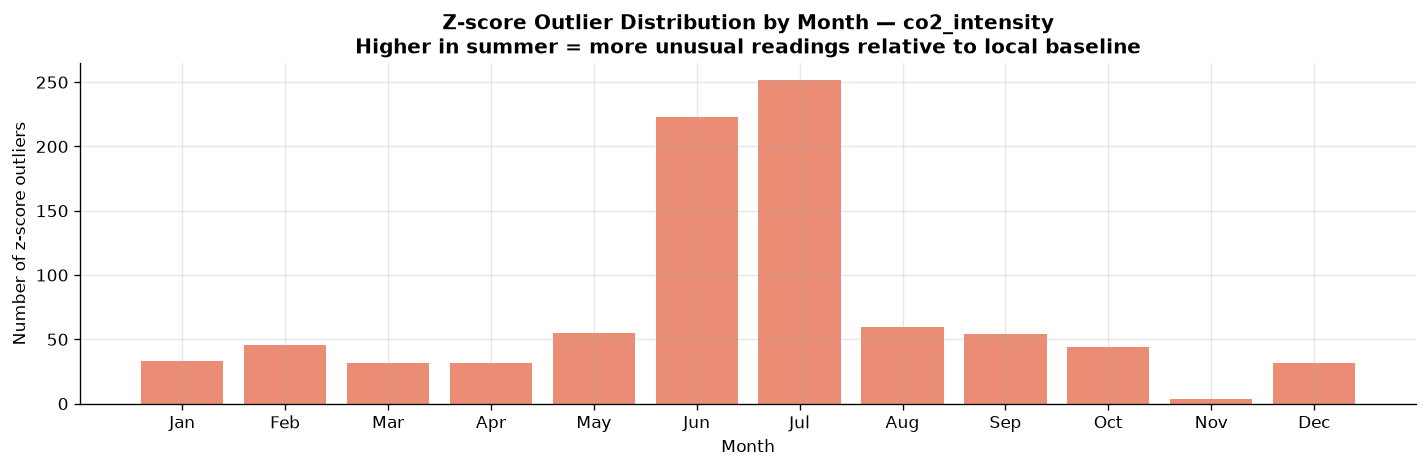

In [216]:
# ── Z-score outlier locations for co2_intensity ─────────────
df_co2   = cleaned["co2_intensity"]
z_flags  = df_co2[df_co2["co2_intensity_zscore_flag"] == 1]

print(f"Total z-score outliers in co2_intensity: {len(z_flags):,}")
if len(z_flags) > 0:
    print("\nOutlier timestamps (first 10):")
    print(z_flags.index[:10].to_list())

    # Plot z-score outlier distribution across months
    fig, ax = plt.subplots(figsize=(12, 4))
    z_flags["month"] = z_flags.index.month
    counts = z_flags.groupby("month").size()
    month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]
    ax.bar([month_labels[m-1] for m in counts.index],
           counts.values, color=RED, alpha=0.8)
    ax.set_xlabel("Month")
    ax.set_ylabel("Number of z-score outliers")
    ax.set_title("Z-score Outlier Distribution by Month — co2_intensity\n"
                 "Higher in summer = more unusual readings relative to local baseline",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/stage3_zscore_monthly.png",
                dpi=130, bbox_inches="tight")
    plt.show()


---
## Stage 4 — Aggregate to 15-Minute Resolution
**Now that each source is clean at 3-minute level, aggregate to hourly buckets.**

**Output columns per source (averages only):**
- MW sources: `{label}_mean` and `{label}_count`
- Intensity sources: `{label}_simple_avg`, `{label}_weighted_avg`, `{label}_count`

**No sums or MWh columns** — averages only as requested.

**Count column (max=5):** shows how many of the 5 possible 3-min slots had valid data in each 15-min bucket. A count of 3 means 2 slots were NaN — the mean is still computed from 3 valid readings, and you can filter `count >= 4` for 80% coverage quality threshold.

**Why weighted average for intensity?**
`simple_avg` treats all 5 slots equally. `weighted_avg` weights each slot by the production MW — a high-production slot contributes more CO₂ and should count more in the average. For CO₂ tonne calculations, weighted is more accurate.


In [217]:
import pandas as pd
import numpy as np
import gc

# Standardize user strings to Pandas Resample Rules
FREQ_MAP = {
    "15min":   "15min",
    "hourly":  "h",
    "daily":   "d",
    "weekly":  "W",
    "monthly": "ME",  # Month End
    "yearly":  "YE"   # Year End
}

def get_key_cols_for_freq(freq_str: str) -> list[str]:
    """Dynamically drops child keys that don't belong in a macro calendar period."""
    rule = FREQ_MAP.get(freq_str.lower(), freq_str)
    if rule in ["15min", "h"]:
        return ["timestamp_utc", "year", "month", "day", "hour", "minute_bucket"]
    elif rule == "d":
        return ["timestamp_utc", "year", "month", "day"]
    elif rule in ["W", "ME"]:
        return ["timestamp_utc", "year", "month"]
    elif rule == "YE":
        return ["timestamp_utc", "year"]
    return ["timestamp_utc"]

def add_time_metadata(df: pd.DataFrame, keys: list[str]) -> pd.DataFrame:
    """Extracts calendar columns from the DatetimeIndex based on active keys."""
    # Ensure index is in UTC string format matching your output requirements
    df["timestamp_utc"] = df.index.strftime("%Y-%m-%dT%H:%M:%SZ")
    if "year" in keys:          df["year"]          = df.index.year
    if "month" in keys:         df["month"]         = df.index.month
    if "day" in keys:           df["day"]           = df.index.day
    if "hour" in keys:          df["hour"]          = df.index.hour
    if "minute_bucket" in keys: df["minute_bucket"] = df.index.minute
    return df

def aggregate_mw_source(df: pd.DataFrame, col: str, label: str, freq_str: str) -> pd.DataFrame:
    rule = FREQ_MAP.get(freq_str.lower(), freq_str)
    keys = get_key_cols_for_freq(freq_str)
    
    # Core aggregation via resample
    resampled = df[col].resample(rule)
    agg = resampled.agg(mean_val="mean", count_val="count")
    
    # Clean up index metadata
    agg = add_time_metadata(agg, keys)
    return agg.reset_index(drop=True)[keys + ["mean_val", "count_val"]].rename(
        columns={"mean_val": f"{label}_mean", "count_val": f"{label}_count"}
    )

def aggregate_intensity_source(df_int: pd.DataFrame, col_int: str,
                                label: str,
                                df_weight: pd.DataFrame,
                                col_weight: str,
                                freq_str: str) -> pd.DataFrame:
    
    rule = FREQ_MAP.get(freq_str.lower(), freq_str)
    keys = get_key_cols_for_freq(freq_str)
    
    # 1. Simple average calculation
    simple_res = (
    df_int[col_int]
    .resample(rule)
    .agg(["mean", "count"])
    .rename(columns={
        "mean": "simple_avg",
        "count": "count_val"
    })
    )
    simple = add_time_metadata(simple_res, keys).reset_index(drop=True)
    simple = simple.rename(columns={"simple_avg": f"{label}_simple_avg", "count_val": f"{label}_count"})
    
    if df_weight is None or df_weight.empty:
        simple[f"{label}_weighted_avg"] = np.nan
        return simple[keys + [f"{label}_simple_avg", f"{label}_count", f"{label}_weighted_avg"]]

    # 2. Weighted average calculation (Vectorized alignment via 3min floor)
    df_i = df_int[[col_int]].copy()
    df_w = df_weight[[col_weight]].copy()
    
    df_i["b3"] = df_i.index.tz_convert("UTC").floor("3min")
    df_w["b3"] = df_w.index.tz_convert("UTC").floor("3min")
    
    # Clear index collisions before merging
    merged = pd.merge(df_i.reset_index(), df_w.reset_index()[["b3", col_weight]], on="b3", how="left")
    merged.set_index("start_time", inplace=True) # Resetting back to DatetimeIndex
    
    # Calculate operational tracking values
    merged["ix_w"] = merged[col_int] * merged[col_weight]
    
    # Resample products and weights simultaneously (Fast execution, no loops!)
    w_resampled = merged[["ix_w", col_weight]].resample(rule).sum(min_count=1)
    
    w_resampled[f"{label}_weighted_avg"] = np.where(
        w_resampled[col_weight] > 0, 
        w_resampled["ix_w"] / w_resampled[col_weight], 
        np.nan
    )
    
    w_agg = add_time_metadata(w_resampled, keys).reset_index(drop=True)
    
    # Merge metrics back together on the structured keys
    return simple.merge(w_agg[keys + [f"{label}_weighted_avg"]], on=keys, how="left")


In [218]:
print(f"Aggregating each cleaned source to {TARGET_FREQUENCY} calendar periods using resample...")
frames = []

for table_name, label, agg_type in SOURCES:
    df_c = cleaned[table_name]
    if agg_type == "mean":
        agg = aggregate_mw_source(df_c, table_name, label, freq_str=TARGET_FREQUENCY)
        print(f"  {table_name:30s} -> {label}_mean  ({len(agg):,} rows)")
    else:
        wt = INTENSITY_WEIGHTS.get(table_name)
        df_w = cleaned.get(wt)
        agg = aggregate_intensity_source(df_c, table_name, label, df_w, wt, freq_str=TARGET_FREQUENCY)
        print(f"  {table_name:30s} -> {label}_simple_avg + weighted_avg  ({len(agg):,} rows)")
    frames.append(agg)
    gc.collect()


Aggregating each cleaned source to 15min calendar periods using resample...
  co2_intensity                  -> co2_intensity_simple_avg + weighted_avg  (302,368 rows)
  consumption_co2_intensity      -> consumption_co2_intens_simple_avg + weighted_avg  (302,369 rows)
  chp_district                   -> chp_district_mw_mean  (302,369 rows)
  chp_industrial                 -> chp_industrial_mw_mean  (302,369 rows)
  hydro                          -> hydro_mw_mean  (302,369 rows)
  nuclear                        -> nuclear_mw_mean  (302,369 rows)
  wind                           -> wind_mw_mean  (302,369 rows)
  total_production               -> total_production_mw_mean  (302,368 rows)
  consumption_electricity        -> consumption_elec_mw_mean  (302,369 rows)


---
## Stage 5 — Merge All hourly Frames
**Inner join on timestamp_utc** — a gap in one source does remove the row from all other sources. The `count` columns show which buckets have incomplete data.


In [219]:
# --- Dynamic Key Resolution for Merging ---
# Dynamically extract active keys based on your chosen target frequency scale
current_key_cols = get_key_cols_for_freq(TARGET_FREQUENCY)

# Merge all generated dataframes using the dynamic time key structure
df_merged = frames[0]
for f in frames[1:]:
    df_merged = df_merged.merge(f, on=current_key_cols, how="inner")
df_merged = df_merged.sort_values(current_key_cols).reset_index(drop=True)

print(f"Merged shape : {df_merged.shape}")
print(f"Date range   : {df_merged['timestamp_utc'].min()} -> "
      f"{df_merged['timestamp_utc'].max()}")
print(f"Total {TARGET_FREQUENCY} buckets: {len(df_merged):,}")
print()

# Drop sum and MWh columns (averages only as per requirement)
drop_cols = [c for c in df_merged.columns
             if c.endswith("_sum") or c.endswith("_mwh")]
df_merged = df_merged.drop(columns=drop_cols, errors="ignore")
print(f"Columns after dropping sums: {df_merged.shape[1]}")

# --- Dynamic Coverage Calculation ---
# Dynamically define expected 3-minute raw data point samples per target time window
def get_expected_slots(freq_str: str) -> int:
    rule = FREQ_MAP.get(freq_str.lower(), freq_str)
    if rule == "15min": return 5     # 15 mins / 3 mins = 5 slots
    if rule == "h":     return 20    # 60 mins / 3 mins = 20 slots
    if rule == "d":     return 480   # 24 hours * 20 slots = 480 slots
    if rule == "W":     return 3360  # 7 days * 480 slots = 3,360 slots
    if rule == "ME":    return 14400 # ~30 days average placeholder scale
    if rule == "YE":    return 175200# ~365 days average placeholder scale
    return 5

expected_slots = get_expected_slots(TARGET_FREQUENCY)

print(f"\n=== COVERAGE REPORT (% of buckets with all {expected_slots} slots) ===")
count_cols = [c for c in df_merged.columns if c.endswith("_count")]
for col in count_cols:
    # Monthly and yearly lengths vary naturally, check if it hits at least 95% of expected slots
    if TARGET_FREQUENCY in ["monthly", "yearly"]:
        full    = (df_merged[col] >= int(expected_slots * 0.95)).sum()
        partial = ((df_merged[col] > 0) & (df_merged[col] < int(expected_slots * 0.95))).sum()
    else:
        full    = (df_merged[col] == expected_slots).sum()
        partial = ((df_merged[col] > 0) & (df_merged[col] < expected_slots)).sum()
        
    empty   = (df_merged[col] == 0).sum()
    pct     = full / len(df_merged) * 100
    print(f"  {col:42s}: {pct:5.1f}% full  "
          f"{partial:,} partial  {empty:,} empty")


Merged shape : (302368, 26)
Date range   : 2018-01-01T00:00:00Z -> 2026-08-16T15:45:00Z
Total 15min buckets: 302,368

Columns after dropping sums: 26

=== COVERAGE REPORT (% of buckets with all 5 slots) ===
  co2_intensity_count                       :  95.3% full  3,848 partial  584 empty
  consumption_co2_intens_count              :  95.3% full  4,148 partial  573 empty
  chp_district_mw_count                     :  96.1% full  1,273 partial  613 empty
  chp_industrial_mw_count                   :  96.2% full  1,251 partial  607 empty
  hydro_mw_count                            :  96.2% full  1,208 partial  596 empty
  nuclear_mw_count                          :  96.1% full  1,352 partial  671 empty
  wind_mw_count                             :  95.6% full  4,990 partial  719 empty
  total_production_mw_count                 :  96.4% full  1,235 partial  611 empty
  consumption_elec_mw_count                 :  96.4% full  1,208 partial  613 empty


In [220]:
df_merged.head(2)

,co2_intensity_simple_avg,co2_intensity_count,timestamp_utc,year,month,day,hour,minute_bucket,co2_intensity_weighted_avg,consumption_co2_intens_simple_avg,...,hydro_mw_mean,hydro_mw_count,nuclear_mw_mean,nuclear_mw_count,wind_mw_mean,wind_mw_count,total_production_mw_mean,total_production_mw_count,consumption_elec_mw_mean,consumption_elec_mw_count
0,99.337196,5,2018-01-01T00:00:00Z,2018,1,1,0,0,99.334301,102.796,...,1316.599998,5,2790.8,5,936.693994,5,8013.94,5,9518.899998,5
1,100.213996,5,2018-01-01T00:15:00Z,2018,1,1,0,15,100.213941,108.324,...,1260.560000,5,2790.3,5,931.494000,5,7956.92,5,9411.359994,5


In [221]:
list(df_merged.columns)

['co2_intensity_simple_avg',
 'co2_intensity_count',
 'timestamp_utc',
 'year',
 'month',
 'day',
 'hour',
 'minute_bucket',
 'co2_intensity_weighted_avg',
 'consumption_co2_intens_simple_avg',
 'consumption_co2_intens_count',
 'consumption_co2_intens_weighted_avg',
 'chp_district_mw_mean',
 'chp_district_mw_count',
 'chp_industrial_mw_mean',
 'chp_industrial_mw_count',
 'hydro_mw_mean',
 'hydro_mw_count',
 'nuclear_mw_mean',
 'nuclear_mw_count',
 'wind_mw_mean',
 'wind_mw_count',
 'total_production_mw_mean',
 'total_production_mw_count',
 'consumption_elec_mw_mean',
 'consumption_elec_mw_count']

---
## Stage 6 — Exploratory Data Analysis on Merged 15-Minute Data
**EDA on the MERGED, AGGREGATED data — after cleaning, before feature engineering.**

EDA at this stage reveals the true patterns without noise from sensor errors. Findings here directly justify feature engineering choices.

**Plots:**
- A1. Distributions of all columns
- A2. Correlation heatmap
- A3. Daily pattern by hour (justifies hour_sin/cos)
- A4. Seasonal heatmap month × hour (justifies month_sin/cos)
- A5. Wind vs CO₂ intensity scatter (confirms primary predictor)
- A6. Production vs consumption intensity (shows import effect)
- A7. Stationarity check + ADF test
- A8. ACF/PACF → justifies SEQ_LEN = 24


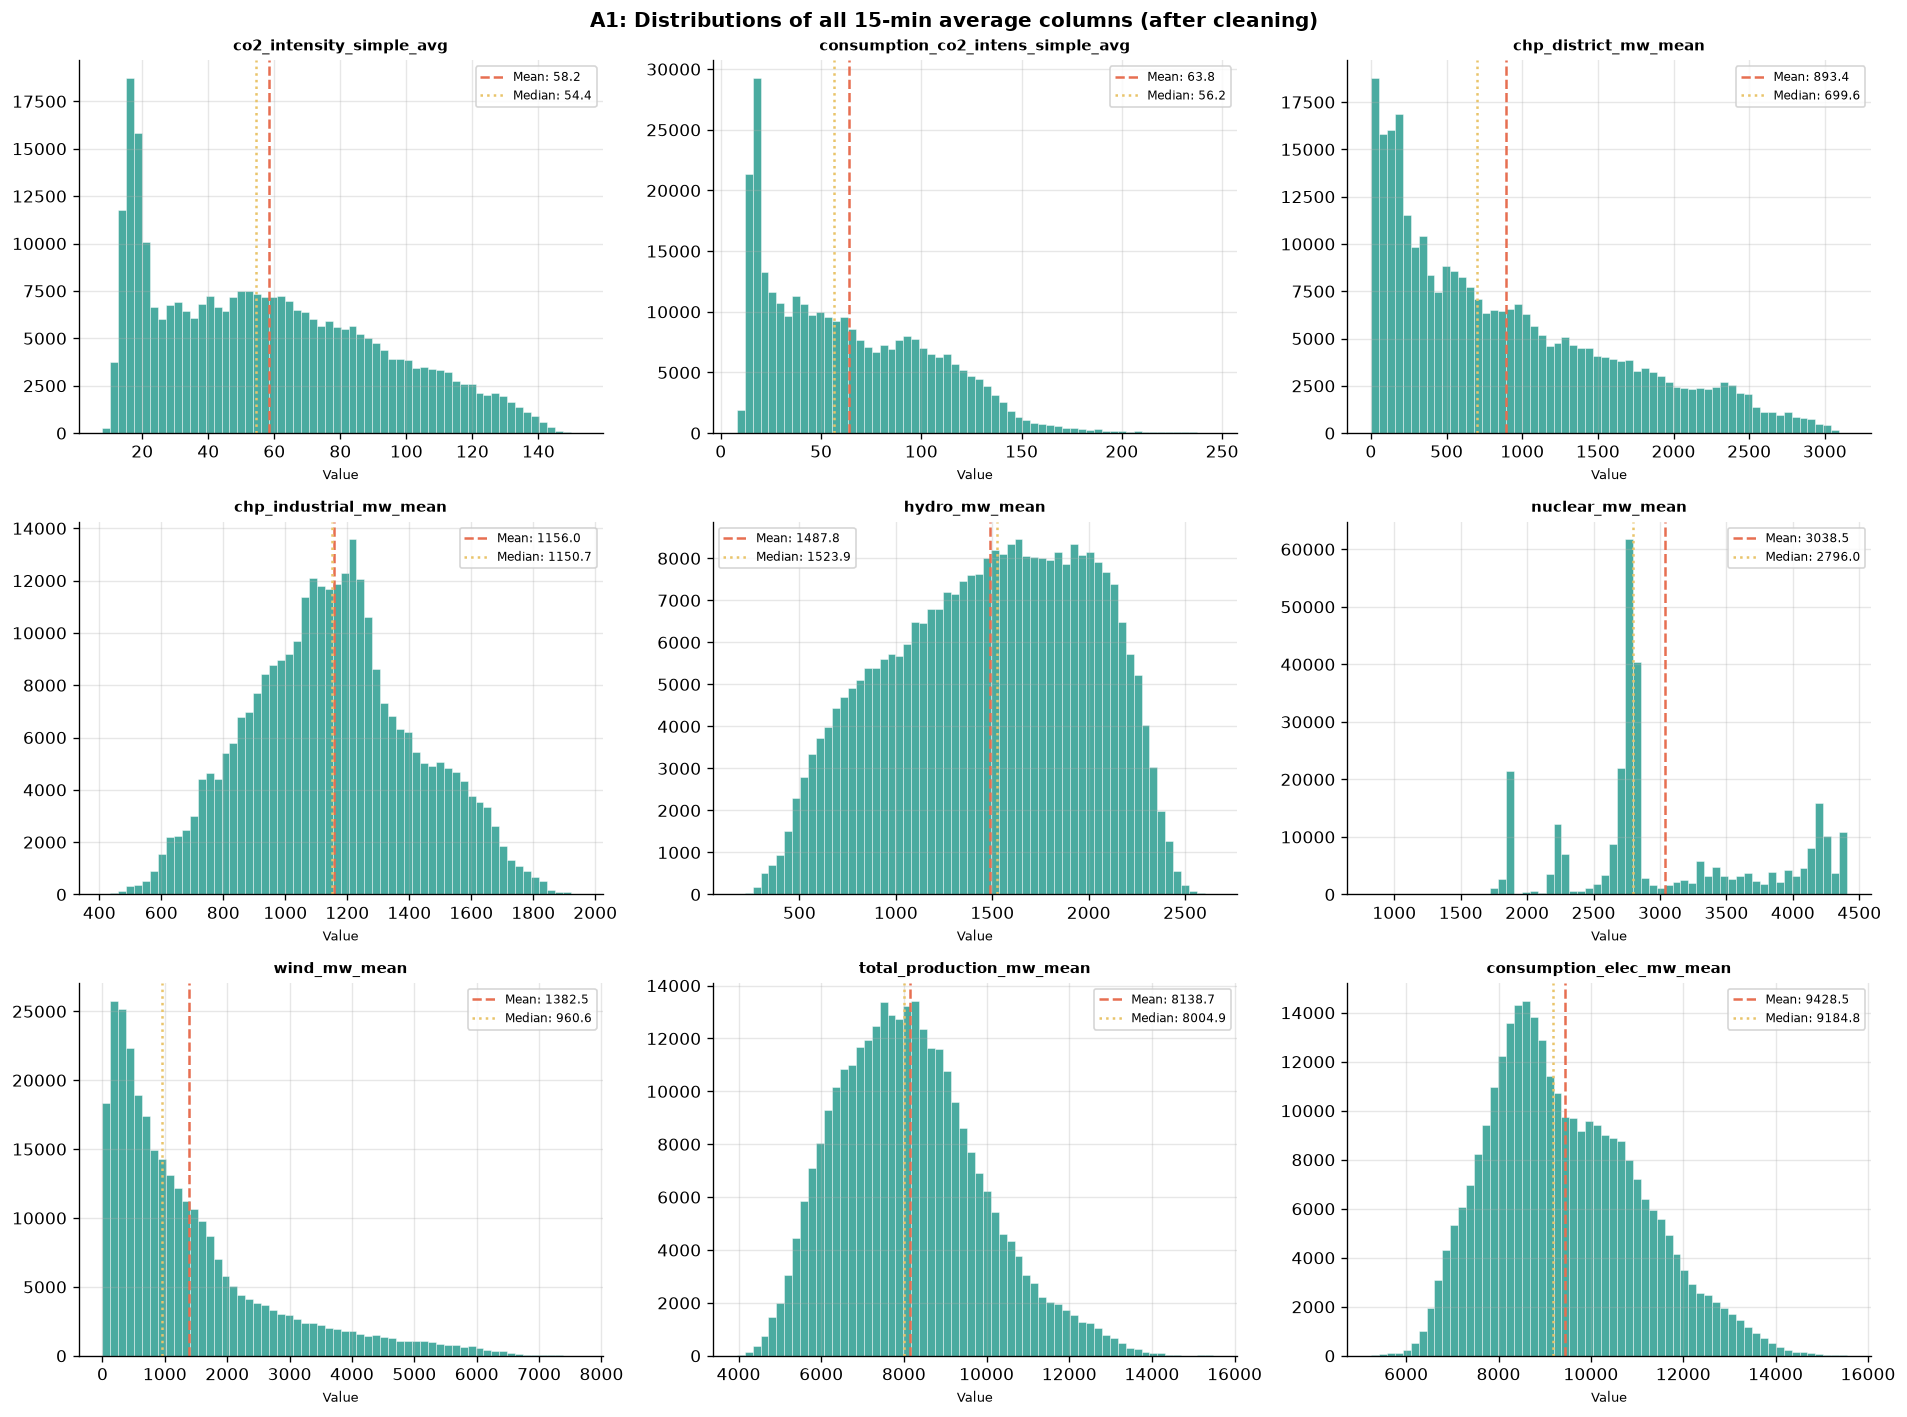

In [222]:
df_eda = df_merged.copy()
df_eda["timestamp_utc"] = pd.to_datetime(df_eda["timestamp_utc"], utc=True)
df_eda = df_eda.set_index("timestamp_utc").sort_index()

# ── A1: Distributions ──────────────────────────────────────
avg_cols = [c for c in df_eda.columns
            if c.endswith("_mean") or c.endswith("_simple_avg")]

n_cols = len(avg_cols)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(avg_cols):
    ax = axes[i]
    data = df_eda[col].dropna()
    ax.hist(data, bins=60, color=TEAL, edgecolor="white",
            linewidth=0.3, alpha=0.85)
    ax.axvline(data.mean(), color=RED, lw=1.5, linestyle="--",
               label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color=AMBER, lw=1.5, linestyle=":",
               label=f"Median: {data.median():.1f}")
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_xlabel("Value", fontsize=8)
    ax.legend(fontsize=7)

for j in range(n_cols, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("A1: Distributions of all 15-min average columns (after cleaning)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_A1_distributions.png",
            dpi=130, bbox_inches="tight")
plt.show()


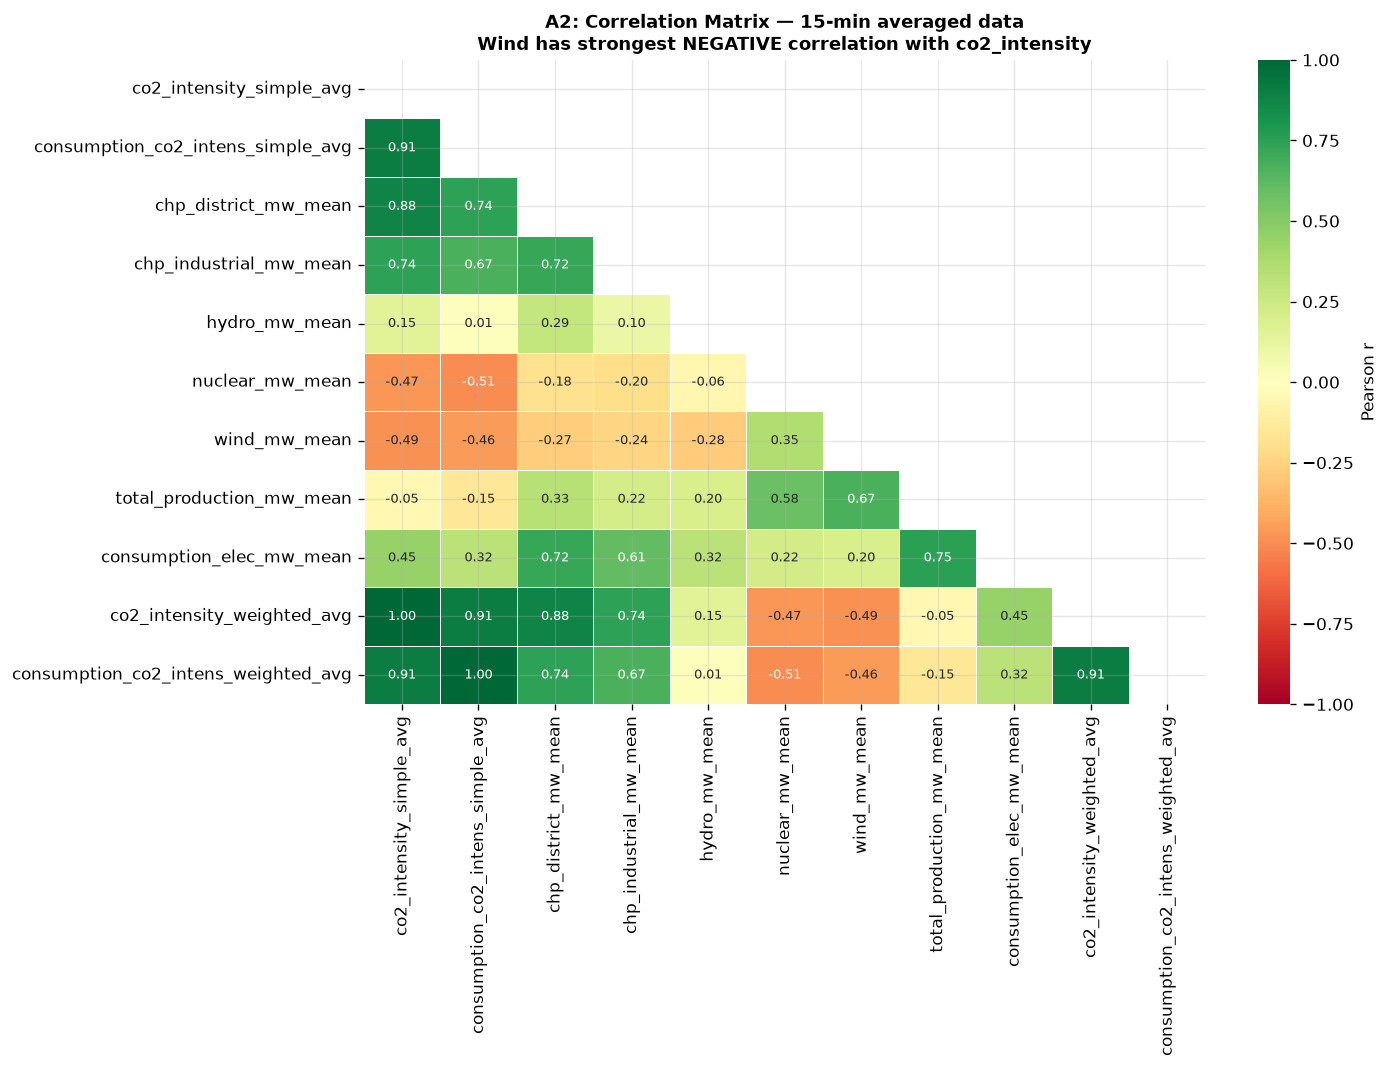

Top correlators with co2_intensity_simple_avg:
co2_intensity_weighted_avg             1.000
consumption_co2_intens_simple_avg      0.910
consumption_co2_intens_weighted_avg    0.910
chp_district_mw_mean                   0.882
chp_industrial_mw_mean                 0.745
wind_mw_mean                           0.490
nuclear_mw_mean                        0.470
consumption_elec_mw_mean               0.452


In [223]:
# ── A2: Correlation heatmap ─────────────────────────────────
corr_cols = avg_cols + ["co2_intensity_weighted_avg",
                         "consumption_co2_intens_weighted_avg"]
corr_cols = [c for c in dict.fromkeys(corr_cols) if c in df_eda.columns]

corr = df_eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, ax=ax,
            linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"label": "Pearson r"},
            annot_kws={"size": 8})
ax.set_title("A2: Correlation Matrix — 15-min averaged data\n"
             "Wind has strongest NEGATIVE correlation with co2_intensity",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_A2_correlation.png",
            dpi=130, bbox_inches="tight")
plt.show()

# Print top correlators with co2_intensity
target = "co2_intensity_simple_avg"
if target in corr.columns:
    top = corr[target].drop(target).abs().sort_values(ascending=False)
    print("Top correlators with co2_intensity_simple_avg:")
    print(top.head(8).round(3).to_string())


In [224]:
# # ── A3: Daily pattern ──────────────────────────────────────
# # JUSTIFIES: hour_sin / hour_cos cyclical features
# target_col = "co2_intensity_simple_avg"
# df_eda["hour_of_day"] = df_eda["hour"]

# hourly_stats = df_eda.groupby("hour_of_day")[target_col].agg(["mean","std"])

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ax = axes[0]
# ax.plot(hourly_stats.index, hourly_stats["mean"],
#         color=BLUE, lw=2, label="Mean")
# ax.fill_between(hourly_stats.index,
#                 hourly_stats["mean"] - hourly_stats["std"],
#                 hourly_stats["mean"] + hourly_stats["std"],
#                 alpha=0.2, color=BLUE, label="±1 std")
# ax.set_xlabel("Hour of day (UTC)")
# ax.set_ylabel("CO2 intensity (gCO2/kWh)")
# ax.set_title("Average CO2 intensity by hour of day\n"
#              "JUSTIFIES: hour_sin/hour_cos features", fontweight="bold")
# ax.set_xticks(range(0, 24, 2))
# ax.legend()

# # Weekday vs weekend
# ax2 = axes[1]
# df_eda["is_wkend"] = df_eda.index.dayofweek >= 5
# for is_wkend, label, color in [(False,"Weekday",BLUE),(True,"Weekend",RED)]:
#     vals = df_eda[df_eda["is_wkend"]==is_wkend].groupby("hour_of_day")[target_col].mean()
#     ax2.plot(vals.index, vals.values, color=color, lw=2,
#              marker="o", ms=4, label=label)
# ax2.set_xlabel("Hour of day (UTC)")
# ax2.set_ylabel("CO2 intensity (gCO2/kWh)")
# ax2.set_title("Weekday vs Weekend profile\n"
#               "JUSTIFIES: is_weekend and dow_sin/cos features", fontweight="bold")
# ax2.set_xticks(range(0, 24, 2))
# ax2.legend()

# plt.suptitle("A3: Daily Pattern Analysis", fontsize=12, fontweight="bold")
# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/eda_A3_daily_pattern.png",
#             dpi=130, bbox_inches="tight")
# plt.show()


In [225]:
# # ── A4: Seasonal heatmap (month x hour) ────────────────────
# # JUSTIFIES: month_sin / month_cos features
# # Most informative single EDA plot for seasonality.
# df_eda["month_num"] = df_eda.index.month
# pivot = df_eda.groupby(["month_num","hour_of_day"])[target_col].mean().unstack()
# month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
#                 "Jul","Aug","Sep","Oct","Nov","Dec"]

# fig, ax = plt.subplots(figsize=(14, 6))
# sns.heatmap(pivot, cmap="RdYlGn_r", ax=ax,
#             xticklabels=[str(h) if h%2==0 else "" for h in range(24)],
#             yticklabels=month_labels,
#             cbar_kws={"label": "Mean CO2 intensity (gCO2/kWh)"})
# ax.set_xlabel("Hour of day (UTC)")
# ax.set_ylabel("Month")
# ax.set_title("A4: Seasonal Heatmap — Month × Hour of Day\n"
#              "Dark red = high intensity (Finnish winter mornings). "
#              "JUSTIFIES: month_sin/cos features.", fontweight="bold")
# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/eda_A4_seasonal_heatmap.png",
#             dpi=130, bbox_inches="tight")
# plt.show()


In [226]:
# # ── A5: Wind vs CO2 scatter ─────────────────────────────────
# target_col = "co2_intensity_simple_avg"
# wind_col = "wind_mw_mean"
# if wind_col in df_eda.columns and target_col in df_eda.columns:
#     sample = df_eda[[wind_col, target_col]].dropna().sample(
#         n=min(30000, len(df_eda)), random_state=42
#     )
#     sample["month_n"] = sample.index.month

#     fig, ax = plt.subplots(figsize=(9, 7))
#     sc = ax.scatter(sample[wind_col], sample[target_col],
#                     c=sample["month_n"], cmap="RdYlGn_r",
#                     alpha=0.15, s=3)
#     plt.colorbar(sc, ax=ax, label="Month")
#     r = sample[[wind_col, target_col]].corr().iloc[0, 1]
#     ax.text(0.05, 0.93, f"Pearson r = {r:.3f}",
#             transform=ax.transAxes, fontsize=11,
#             color=BLUE, fontweight="bold",
#             bbox=dict(boxstyle="round,pad=0.3",
#                       facecolor="white", alpha=0.8))
#     ax.set_xlabel("Wind generation mean (MW)")
#     ax.set_ylabel("CO2 intensity simple avg (gCO2/kWh)")
#     ax.set_title("A5: Wind vs CO2 Intensity (coloured by month)\n"
#                  "Strongest predictor — wind up = intensity down", fontweight="bold")
#     plt.tight_layout()
#     plt.savefig(f"{OUTPUT_DIR}/eda_A5_wind_scatter.png",
#                 dpi=130, bbox_inches="tight")
#     plt.show()
#     print(f"Correlation wind vs co2_intensity: {r:.3f}")


In [227]:
# # ── A6: Production vs consumption intensity ─────────────────
# prod_col = "co2_intensity_simple_avg"
# cons_col = "consumption_co2_intens_simple_avg"
# if prod_col in df_eda.columns and cons_col in df_eda.columns:
#     monthly = df_eda[[prod_col, cons_col]].resample("ME").mean()
#     diff    = monthly[cons_col] - monthly[prod_col]

#     fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

#     axes[0].plot(monthly.index, monthly[prod_col],
#                  color=BLUE, lw=1.5, label="Production intensity")
#     axes[0].plot(monthly.index, monthly[cons_col],
#                  color=RED, lw=1.5, linestyle="--", label="Consumption intensity")
#     axes[0].set_ylabel("gCO2/kWh")
#     axes[0].legend()
#     axes[0].set_title("A6: Production vs Consumption CO2 Intensity\n"
#                       "Difference = net import effect (Estonian/Russian fossil imports)",
#                       fontweight="bold")

#     colors = [RED if v > 0 else TEAL for v in diff.values]
#     axes[1].bar(diff.index, diff.values, color=colors, alpha=0.7, width=20)
#     axes[1].axhline(0, color="black", lw=0.8)
#     axes[1].set_ylabel("Consumption minus Production (gCO2/kWh)")
#     axes[1].set_xlabel("Month")
#     axes[1].set_title("Red bars = Finland importing from fossil-heavy grids")
#     axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

#     plt.tight_layout()
#     plt.savefig(f"{OUTPUT_DIR}/eda_A6_prod_vs_cons.png",
#                 dpi=130, bbox_inches="tight")
#     plt.show()


In [228]:
# # ── A7: Stationarity check ──────────────────────────────────
# series = df_eda[target_col].dropna()

# adf_raw  = adfuller(series.iloc[:5000])
# adf_diff = adfuller(series.diff().dropna().iloc[:5000])

# print("=== STATIONARITY TESTS ===")
# print(f"Raw series ADF    : stat={adf_raw[0]:.4f}  p={adf_raw[1]:.4f}  "
#       f"-> {'STATIONARY' if adf_raw[1]<0.05 else 'NON-STATIONARY'}")
# print(f"Differenced ADF   : stat={adf_diff[0]:.4f}  p={adf_diff[1]:.4f}  "
#       f"-> {'STATIONARY' if adf_diff[1]<0.05 else 'NON-STATIONARY'}")
# print()
# print("CONCLUSION for LSTM/GRU:")
# print("  Do NOT difference. LSTM handles trends directly.")
# print("  Include time_index feature (0 to 1) to represent the long-term trend.")
# print("  Differencing adds noise and loses absolute level information needed")
# print("  for accurate gCO2/kWh predictions.")

# # Long-term trend
# annual = df_eda[target_col].resample("YE").mean().dropna()
# if len(annual) >= 2:
#     first, last = annual.iloc[0], annual.iloc[-1]
#     pct = (first - last) / first * 100
#     fig, ax = plt.subplots(figsize=(12, 4))
#     ax.plot(annual.index, annual.values,
#             color=RED, lw=2.5, marker="o", ms=7)
#     ax.fill_between(annual.index, annual.values, alpha=0.15, color=RED)
#     ax.set_title(f"A7: Annual Mean CO2 Intensity — {pct:.0f}% reduction "
#                  f"({first:.0f} to {last:.0f} gCO2/kWh)\n"
#                  "Non-stationary due to this downward trend → include time_index feature",
#                  fontweight="bold")
#     ax.set_ylabel("gCO2/kWh")
#     ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
#     plt.tight_layout()
#     plt.savefig(f"{OUTPUT_DIR}/eda_A7_trend.png",
#                 dpi=130, bbox_inches="tight")
#     plt.show()


---
## Stage 7 — Feature Engineering
**Applied to the merged 15-minute table after EDA confirms the patterns.**

All features derived from patterns observed in EDA:
| Feature | What EDA showed | Why it helps |
|---------|-----------------|-------------|
| `hour_sin/cos` | Strong daily cycle in A3 | Encodes 24h cycle without midnight discontinuity |
| `dow_sin/cos` | Weekday vs weekend gap in A3 | Captures weekly demand pattern |
| `month_sin/cos` | Clear seasonality in A4 | Captures Finnish winter/summer cycle |
| `is_weekend` | Industrial reduction visible | Binary demand signal |
| `time_index` | 77% downward trend in A7 | Models long-term grid decarbonisation |
| `*_lag1/4/96/672` | ACF shows lag-96 dominance | Explicit memory at key intervals |
| `*_rmean/rstd` | Volatility visible in A5 | Recent level and uncertainty signal |
| `renewable_share` | Direct from correlation A2 | Single most informative derived feature |
| `net_load` | Physical relationship | How much fossil CHP must dispatch |


In [229]:
# --- Dynamic Step Configuration Rules ---
# Translates standard structural concepts to index steps based on TARGET_FREQUENCY
import pandas as pd
import numpy as np


# ═════════════════════════════════════════════════════════════
# DYNAMIC LAG / ROLLING CONFIGURATION
# ═════════════════════════════════════════════════════════════

def get_dynamic_steps(freq_str: str) -> tuple[list[int], list[int]]:
    """
    Return frequency-appropriate lag steps and rolling windows.

    LAG_STEPS:
        Used for lag features, e.g. col_lag1, col_lag4, ...

    ROLL_WINDOWS:
        Used for rolling mean/std features, e.g. rmean4, rstd4, ...

    Values are expressed in number of observations at the
    selected TARGET_FREQUENCY.

    Project configuration:

        15-min:
            lags    = [1, 4, 96, 672]
            rolling = [4, 96]

        hourly:
            lags    = [1, 6, 24, 168]
            rolling = [6, 24]

        daily:
            lags    = [1, 7, 30, 365]
            rolling = [7, 30]

        weekly:
            lags    = [1, 4, 13, 52]
            rolling = [4, 13]

        monthly:
            lags    = [1, 3, 12, 24]
            rolling = [3, 12]

        yearly:
            no lag/rolling features; deep learning is not used.
    """

    freq = freq_str.lower().strip()

    configs = {
        "15min": {
            "lags": [1, 4, 96, 672],
            "rolling": [4, 96],
        },

        "hourly": {
            "lags": [1, 6, 24, 168],
            "rolling": [6, 24],
        },

        "daily": {
            "lags": [1, 7, 30, 365],
            "rolling": [7, 30],
        },

        "weekly": {
            "lags": [1, 4, 13, 52],
            "rolling": [4, 13],
        },

        "monthly": {
            "lags": [1, 3, 12, 24],
            "rolling": [3, 12],
        },

        "yearly": {
            "lags": [],
            "rolling": [],
        },
    }

    if freq not in configs:
        raise ValueError(
            f"Unsupported TARGET_FREQUENCY='{freq_str}'. "
            f"Choose one of: {list(configs.keys())}"
        )

    return (
        configs[freq]["lags"],
        configs[freq]["rolling"],
    )


LAG_STEPS, ROLL_WINDOWS = get_dynamic_steps(TARGET_FREQUENCY)

print(f"\n=== FEATURE WINDOW CONFIGURATION ===")
print(f"Target frequency : {TARGET_FREQUENCY}")
print(f"LAG_STEPS        : {LAG_STEPS}")
print(f"ROLL_WINDOWS     : {ROLL_WINDOWS}")

df_feat = df_merged.copy()
df_feat["timestamp_utc"] = pd.to_datetime(df_feat["timestamp_utc"], utc=True)
df_feat = df_feat.set_index("timestamp_utc").sort_index()

print("Index dtype:", df_feat.index.dtype)

new_cols = {}

# ── Cyclical Time Features (Dynamic Safety Checks) ──────────
# Only generate short-term cyclical elements if they exist at this time grain
if "hour" in df_feat.columns:
    new_cols["hour_sin"] = np.sin(2 * np.pi * df_feat["hour"] / 24)
    new_cols["hour_cos"] = np.cos(2 * np.pi * df_feat["hour"] / 24)

# Day of week applies to hourly, daily, and weekly views
if TARGET_FREQUENCY in ["15min", "hourly", "daily", "weekly"]:
    new_cols["dow_sin"] = np.sin(2 * np.pi * df_feat.index.dayofweek / 7)
    new_cols["dow_cos"] = np.cos(2 * np.pi * df_feat.index.dayofweek / 7)
    new_cols["is_weekend"] = (df_feat.index.dayofweek >= 5).astype(np.float32)

# Month elements apply universally, unless you aggregate down to yearly summaries
if TARGET_FREQUENCY != "yearly":
    # If the source dataframe dropped the explicit 'month' field during macro-resampling,
    # pull it directly from the continuous DatetimeIndex mapping safely.
    month_src = df_feat["month"] if "month" in df_feat.columns else df_feat.index.month
    new_cols["month_sin"] = np.sin(2 * np.pi * month_src / 12)
    new_cols["month_cos"] = np.cos(2 * np.pi * month_src / 12)

# ── Normalized Time Index ───────────────────────────────────
t_range = df_feat.index.max() - df_feat.index.min()

t_min = df_feat.index.min().timestamp()
t_max = df_feat.index.max().timestamp()
print("t_min using .timestamp():", t_min)
print("t_max using .timestamp():", t_max)

if t_range.total_seconds() > 0:
    new_cols["time_index"] = ((df_feat.index - df_feat.index.min()) / t_range).astype(np.float32)
else:
    new_cols["time_index"] = np.zeros(len(df_feat), dtype=np.float32)

time_idx = new_cols["time_index"]

print("dtype:", time_idx.dtype)

print("\nFirst 5:")
print(time_idx[:5])

print("\nLast 5:")
print(time_idx[-5:])

print("\nStatistics:")
print(pd.Series(time_idx).describe())

print("\nMin:", time_idx.min())
print("Max:", time_idx.max())

df_feat = pd.concat([df_feat, pd.DataFrame(new_cols, index=df_feat.index)], axis=1)
print(f"After time features: {df_feat.shape[1]} columns")

# ── Rate-of-change features ─────────────────────────────────
# Dynamically pull the first two step lengths from our dynamic config list
diff1_step = LAG_STEPS[0]
diff4_step = LAG_STEPS[1]

for col in ["co2_intensity_simple_avg", "consumption_co2_intens_simple_avg"]:
    if col in df_feat.columns:
        df_feat[f"{col}_diff{diff1_step}"] = df_feat[col].diff(diff1_step)
        df_feat[f"{col}_diff{diff4_step}"] = df_feat[col].diff(diff4_step)

print(f"Rate-of-change features added for steps: {diff1_step} and {diff4_step}")
print(f"After rate-of-change features: {df_feat.shape[1]} columns")

# ── Identify signal columns for lags ───────────────────────
MEAN_COLS = [c for c in df_feat.columns if c.endswith("_mean")]
INT_COLS  = [c for c in df_feat.columns if c.endswith("_simple_avg") or c.endswith("_weighted_avg")]
SIG_COLS  = MEAN_COLS + INT_COLS

# ── Lag features (Using Dynamic Windowing Arrays) ───────────
lag_frames = {}
for col in SIG_COLS:
    if col in df_feat.columns:
        for lag in LAG_STEPS:
            lag_frames[f"{col}_lag{lag}"] = df_feat[col].shift(lag)

df_feat = pd.concat([df_feat, pd.DataFrame(lag_frames, index=df_feat.index)], axis=1)
print(f"After lag features : {df_feat.shape[1]} columns")

# ── Rolling statistics (Using Dynamic Windowing Arrays) ─────
ROLL_COLS = [
    "co2_intensity_simple_avg", "consumption_co2_intens_simple_avg", "wind_mw_mean", 
    "hydro_mw_mean", "chp_district_mw_mean", "chp_industrial_mw_mean",
    "nuclear_mw_mean", "total_production_mw_mean", "consumption_elec_mw_mean"
]
roll_frames = {}
for col in ROLL_COLS:
    if col not in df_feat.columns:
        continue
    for w in ROLL_WINDOWS:
        mp = max(1, int(w * 0.5))
        roll_frames[f"{col}_rmean{w}"] = df_feat[col].rolling(w, min_periods=mp).mean()
        roll_frames[f"{col}_rstd{w}"]  = df_feat[col].rolling(w, min_periods=mp).std()

df_feat = pd.concat([df_feat, pd.DataFrame(roll_frames, index=df_feat.index)], axis=1)
print(f"After rolling stats: {df_feat.shape[1]} columns")

# ── Physics-derived features ────────────────────────────────
phys = {}
if all(c in df_feat.columns for c in ["wind_mw_mean", "nuclear_mw_mean", "hydro_mw_mean"]):
    phys["renewable_mw"] = df_feat["wind_mw_mean"] + df_feat["nuclear_mw_mean"] + df_feat["hydro_mw_mean"]
    if "total_production_mw_mean" in df_feat.columns:
        phys["renewable_share"] = phys["renewable_mw"] / (df_feat["total_production_mw_mean"] + 1e-6)
        phys["net_load"]        = df_feat["total_production_mw_mean"] - phys["renewable_mw"]
if all(c in df_feat.columns for c in ["chp_district_mw_mean", "chp_industrial_mw_mean"]):
    phys["fossil_chp_mw"] = df_feat["chp_district_mw_mean"] + df_feat["chp_industrial_mw_mean"]
    if "total_production_mw_mean" in df_feat.columns:
        phys["fossil_share"] = phys["fossil_chp_mw"] / (df_feat["total_production_mw_mean"] + 1e-6)

df_feat = pd.concat([df_feat, pd.DataFrame(phys, index=df_feat.index)], axis=1)
print(f"After physics feats: {df_feat.shape[1]} columns")
print("Feature engineering complete.")



=== FEATURE WINDOW CONFIGURATION ===
Target frequency : 15min
LAG_STEPS        : [1, 4, 96, 672]
ROLL_WINDOWS     : [4, 96]
Index dtype: datetime64[us, UTC]
t_min using .timestamp(): 1514764800.0
t_max using .timestamp(): 1786895100.0
dtype: float32

First 5:
Index([                   0.0,  3.307239239802584e-06,  6.614478479605168e-06,
        9.921717719407752e-06, 1.3228956959210336e-05],
      dtype='float32', name='timestamp_utc')

Last 5:
Index([0.9999867677688599, 0.9999901056289673, 0.9999933838844299,
       0.9999967217445374,                1.0],
      dtype='float32', name='timestamp_utc')

Statistics:
count    302368.000000
mean          0.500000
std           0.288677
min           0.000000
25%           0.250000
50%           0.500000
75%           0.750000
max           1.000000
Name: timestamp_utc, dtype: float64

Min: 0.0
Max: 1.0
After time features: 33 columns
Rate-of-change features added for steps: 1 and 4
After rate-of-change features: 37 columns
After lag featu

---
## Stage 7.1 — Baseline Models
**Purpose:** Establish minimum performance benchmarks before deep learning. A model that does not beat Persistence is not useful.

**Baselines:**
1. **Persistence** — predict last known value. Zero model, zero cost.
2. **Lag-480** — predict same value as exactly 24 hours ago. Captures daily cycle.
3. **Rolling Mean (1h)** — predict 1-hour rolling average. Smoothed trend.
4. **SARIMA sample** — classical statistical model on a small hourly subsample.



**IMPORTANT:** Baselines are computed on the FULL cleaned dataset (before lag dropna), not just the test set, so values differ slightly from the deep learning test-set evaluation.


In [230]:
TARGET_COLS = ["co2_intensity_simple_avg",
                        "consumption_co2_intens_simple_avg"]

print("=== BASELINE MODELS ===")
print()

for target in TARGET_COLS:
    print(f"--- Target: {target} ---")

    # Persistence
    pers_pred = df_feat[target].shift(1)
    pers_mae  = np.mean(np.abs(df_feat[target] - pers_pred).dropna())
    print(f"  Persistence (lag-1)         MAE: {pers_mae:.4f} gCO₂/kWh")

    # Lag-480 (same time yesterday)
    lag480_pred = df_feat[target].shift(480)
    lag480_mae  = np.mean(np.abs(df_feat[target] - lag480_pred).dropna())
    print(f"  Lag-480 (yesterday)         MAE: {lag480_mae:.4f} gCO₂/kWh")

    # Rolling mean (1h)
    rolling_pred = df_feat[target].shift(1).rolling(20).mean()
    rolling_mae  = np.mean(np.abs(df_feat[target] - rolling_pred).dropna())
    print(f"  Rolling mean (1h)           MAE: {rolling_mae:.4f} gCO₂/kWh")
    print()

=== BASELINE MODELS ===

--- Target: co2_intensity_simple_avg ---
  Persistence (lag-1)         MAE: 0.4684 gCO₂/kWh
  Lag-480 (yesterday)         MAE: 11.2886 gCO₂/kWh
  Rolling mean (1h)           MAE: 2.1681 gCO₂/kWh

--- Target: consumption_co2_intens_simple_avg ---
  Persistence (lag-1)         MAE: 0.8830 gCO₂/kWh
  Lag-480 (yesterday)         MAE: 13.3641 gCO₂/kWh
  Rolling mean (1h)           MAE: 4.6654 gCO₂/kWh



co2_intensity_simple_avg',
 'co2_intensity_count',
 'co2_intensity_weighted_avg',
 'consumption_co2_intens_simple_avg',
 'consumption_co2_intens_count',
 'consumption_co2_intens_weighted_avg',
 'chp_district_mw_mean',
 'chp_district_mw_count',
 'chp_industrial_mw_mean',
 'chp_industrial_mw_count',
 'hydro_mw_mean',
 'hydro_mw_count',
 'nuclear_mw_mean',
 'nuclear_mw_count',
 'wind_mw_mean',
 'wind_mw_count',
 'total_production_mw_mean',
 'total_production_mw_count',
 'consumption_elec_mw_mean',
 'consumption_elec_mw_count'

---
## Stage 8 — Define Features
**Critical rules:**
1. Exclude metadata, raw count columns, and intermediate physics columns from features
2. Split on TIME — never shuffle time series
3. Fit MinMaxScaler ONLY on training data — prevents data leakage from test period
4. Use float32 throughout — halves memory vs float64 with no meaningful precision loss


In [231]:
TARGET_COLS = ["co2_intensity_simple_avg",
                        "consumption_co2_intens_simple_avg"]
EXCLUDE = (
    ["year","month","day","hour","minute_bucket","renewable_mw","fossil_chp_mw"]
    + TARGET_COLS
    + TARGET_COLS_WEIGHTED
    + [c for c in df_feat.columns if c.endswith("_count")]
    + [c for c in df_feat.columns if c.endswith("_flag")]
)

# BUGFIX: NO_LAG_ROLLING used to be appended to EXCLUDE *after*
# FEATURE_COLS was already built, so it never actually removed anything --
# the "no lag/rolling" experiment silently kept every lag/rolling column.
# It must run before FEATURE_COLS is computed.
if NO_LAG_ROLLING:
    EXCLUDE += [
        c for c in df_feat.columns
        if "_lag" in c
        or "_rmean" in c
        or "_rstd" in c
        or "_avg_diff" in c
    ]

FEATURE_COLS = [c for c in df_feat.columns
                if c not in EXCLUDE
                and not df_feat[c].isna().all()]



print(f"Frequency       : {TARGET_FREQUENCY}")
print(f"Experiment      : {EXPERIMENT_NAME}")
print(f"Feature columns : {len(FEATURE_COLS)}")
print(f"Target columns  : {TARGET_COLS}")
print()

ALL_COLS = FEATURE_COLS + TARGET_COLS
df_model = df_feat[ALL_COLS].dropna()
print(f"Rows after dropna  : {len(df_model):,}")
print("Data ready for modelling.")


Frequency       : 15min
Experiment      : all_features
Feature columns : 102
Target columns  : ['co2_intensity_simple_avg', 'consumption_co2_intens_simple_avg']

Rows after dropna  : 298,603
Data ready for modelling.


In [232]:
print(FEATURE_COLS)

['chp_district_mw_mean', 'chp_industrial_mw_mean', 'hydro_mw_mean', 'nuclear_mw_mean', 'wind_mw_mean', 'total_production_mw_mean', 'consumption_elec_mw_mean', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'month_sin', 'month_cos', 'time_index', 'co2_intensity_simple_avg_diff1', 'co2_intensity_simple_avg_diff4', 'consumption_co2_intens_simple_avg_diff1', 'consumption_co2_intens_simple_avg_diff4', 'chp_district_mw_mean_lag1', 'chp_district_mw_mean_lag4', 'chp_district_mw_mean_lag96', 'chp_district_mw_mean_lag672', 'chp_industrial_mw_mean_lag1', 'chp_industrial_mw_mean_lag4', 'chp_industrial_mw_mean_lag96', 'chp_industrial_mw_mean_lag672', 'hydro_mw_mean_lag1', 'hydro_mw_mean_lag4', 'hydro_mw_mean_lag96', 'hydro_mw_mean_lag672', 'nuclear_mw_mean_lag1', 'nuclear_mw_mean_lag4', 'nuclear_mw_mean_lag96', 'nuclear_mw_mean_lag672', 'wind_mw_mean_lag1', 'wind_mw_mean_lag4', 'wind_mw_mean_lag96', 'wind_mw_mean_lag672', 'total_production_mw_mean_lag1', 'total_production_mw_mean_lag4'

In [233]:
# Save the model-ready DataFrame into its own frequency/experiment folder
# so runs for different TARGET_FREQUENCY / NO_LAG_ROLLING combinations
# don't overwrite each other, e.g.:
#   test/hourly/all_features/df_model.parquet
#   test/hourly/no_lag_rolling/df_model.parquet
#   test/daily/all_features/df_model.parquet
#   ...
SAVE_DIR = Path("outputs") / TARGET_FREQUENCY / EXPERIMENT_NAME
SAVE_DIR.mkdir(parents=True, exist_ok=True)

df_model.to_parquet(SAVE_DIR / "df_model.parquet", index=True)
print(f"Saved: {SAVE_DIR / 'df_model.parquet'}")

Saved: outputs\15min\all_features\df_model.parquet


In [234]:
import json

with open(SAVE_DIR / "column_config.json", "w") as f:
    json.dump({
        "TARGET_FREQUENCY": TARGET_FREQUENCY,
        "EXPERIMENT_NAME": EXPERIMENT_NAME,
        "NO_LAG_ROLLING": NO_LAG_ROLLING,
        "SEQ_LEN": SEQ_LEN,
        "LAG_STEPS": LAG_STEPS,
        "ROLL_WINDOWS": ROLL_WINDOWS,
        "FEATURE_COLS": FEATURE_COLS,
        "TARGET_COLS": TARGET_COLS,
        "TRAIN_RATIO": 0.70,
        "VAL_RATIO": 0.15,
        "TEST_RATIO": 0.15
    }, f, indent=2)

print(f"Saved: {SAVE_DIR / 'column_config.json'}")
print(f"Preprocessing complete for frequency='{TARGET_FREQUENCY}', experiment='{EXPERIMENT_NAME}'.")
print(f"-> {SAVE_DIR}/df_model.parquet")
print(f"-> {SAVE_DIR}/column_config.json")

Saved: outputs\15min\all_features\column_config.json
Preprocessing complete for frequency='15min', experiment='all_features'.
-> outputs\15min\all_features/df_model.parquet
-> outputs\15min\all_features/column_config.json
